##  Advanced Image Manipulation & Background Subtraction

Image Inpainting using OpenCV

In [1]:
import cv2
import numpy as np

# reading the damaged image
damaged_img = cv2.imread(filename=r"images\image.png")

# get the shape of the image
height, width = damaged_img.shape[0], damaged_img.shape[1]

# Converting all pixels greater than zero to black while black becomes white
for i in range(height):
    for j in range(width):
        if damaged_img[i, j].sum() > 0:
            damaged_img[i, j] = 0
        else:
            damaged_img[i, j] = [255, 255, 255]

# saving the mask 
mask = damaged_img
cv2.imwrite('mask.jpg', mask)

# displaying mask
cv2.imshow("damaged image mask", mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import numpy as np
import cv2

# Use raw string (important in Windows)
img = cv2.imread(r'images\image.png')
mask = cv2.imread(r'images\image1.png', 0)

# Check if images loaded properly
if img is None:
    print("Image not found!")
if mask is None:
    print("Mask not found!")

# Resize mask to match image size
mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

# Ensure mask is binary (0 and 255 only)
_, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# Inpaint
dst = cv2.inpaint(img, mask, 3, cv2.INPAINT_NS)

# Save result
cv2.imwrite('cat_inpainted.png', dst)

print("Done ✅")


Done ✅


Python | Image Registration using OpenCV

In [ ]:
import cv2
import numpy as np

img1_color = cv2.imread(r"images\image.png")
img2_color = cv2.imread(r"images\image1.png")

if img1_color is None or img2_color is None:
    print("❌ Check image path!")
    exit()

img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)
height, width = img2.shape

orb_detector = cv2.ORB_create(5000)

kp1, d1 = orb_detector.detectAndCompute(img1, None)
kp2, d2 = orb_detector.detectAndCompute(img2, None)

matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = list(matcher.match(d1, d2))   # ⭐ FIX HERE
matches.sort(key=lambda x: x.distance)

matches = matches[:int(len(matches)*0.9)]
no_of_matches = len(matches)

p1 = np.zeros((no_of_matches, 2))
p2 = np.zeros((no_of_matches, 2))

for i in range(no_of_matches):
    p1[i] = kp1[matches[i].queryIdx].pt
    p2[i] = kp2[matches[i].trainIdx].pt

homography, _ = cv2.findHomography(p1, p2, cv2.RANSAC)

transformed_img = cv2.warpPerspective(img1_color, homography, (width, height))

cv2.imwrite('output.jpg', transformed_img)

print("✅ Done")


✅ Done


Python | Background subtraction using OpenCV

In [2]:
import numpy as np
import cv2

# Load video file
cap = cv2.VideoCapture('images\image.png')

# Create background subtractor (MOG2 handles shadows well)
fgbg = cv2.createBackgroundSubtractorMOG2()

while True:
    ret, frame = cap.read()
    if not ret:
        break  # Stop if video ends

    # Apply background subtraction
    fgmask = fgbg.apply(frame)

    # Show original and foreground mask side by side
    cv2.imshow('Original Frame', frame)
    cv2.imshow('Foreground Mask', fgmask)

    # Press 'Esc' to exit
    if cv2.waitKey(30) & 0xFF == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

Background Subtraction in an Image using Concept of Running Average

In [ ]:
import cv2
import numpy as np

# Capture video from webcam
cap = cv2.VideoCapture(0)

# Read the first frame and convert to float
_, img = cap.read()
averageValue1 = np.float32(img)

while True:
    # Capture next frame
    _, img = cap.read()
    
    # Update background model
    cv2.accumulateWeighted(img, averageValue1, 0.02)
    
    # Convert back to 8-bit for display
    resultingFrames1 = cv2.convertScaleAbs(averageValue1)

    # Show both original and background model
    cv2.imshow('Original Frame', img)
    cv2.imshow('Background (Running Average)', resultingFrames1)
    
    # Exit on Esc key
    if cv2.waitKey(30) & 0xFF == 27:
        break

# Cleanup
cap.release()
cv2.destroyAllWindows()

Foreground Extraction in an Image using Grabcut Algorithm

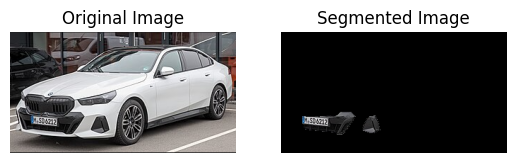

In [ ]:
# Python program to illustrate foreground extraction using GrabCut algorithm

# organize imports
import numpy as np
import cv2
from matplotlib import pyplot as plt
 
# path to input image specified and 
# image is loaded with imread command
image = cv2.imread('images\image1.png')
 
# create a simple mask image similar
# to the loaded image, with the 
# shape and return type
mask = np.zeros(image.shape[:2], np.uint8)
 
# specify the background and foreground model
# using numpy the array is constructed of 1 row
# and 65 columns, and all array elements are 0
# Data type for the array is np.float64 (default)
backgroundModel = np.zeros((1, 65), np.float64)
foregroundModel = np.zeros((1, 65), np.float64)
 
# define the Region of Interest (ROI)
# as the coordinates of the rectangle
# where the values are entered as
# (startingPoint_x, startingPoint_y, width, height)
# these coordinates are according to the input image
# it may vary for different images
rectangle = (20, 100, 150, 150)
 
# apply the grabcut algorithm with appropriate
# values as parameters, number of iterations = 3 
# cv2.GC_INIT_WITH_RECT is used because
# of the rectangle mode is used 
cv2.grabCut(image, mask, rectangle,  
            backgroundModel, foregroundModel,
            3, cv2.GC_INIT_WITH_RECT)
 
# In the new mask image, pixels will 
# be marked with four flags 
# four flags denote the background / foreground 
# mask is changed, all the 0 and 2 pixels 
# are converted to the background
# mask is changed, all the 1 and 3 pixels
# are now the part of the foreground
# the return type is also mentioned,
# this gives us the final mask
mask2 = np.where((mask == 2)|(mask == 0), 0, 1).astype('uint8')
 
# The final mask is multiplied with 
# the input image to give the segmented image.
image_segmented = image * mask2[:, :, np.newaxis]
 
# output segmented image with colorbar
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Display the segmented image
plt.subplot(1, 2, 2)
plt.title('Segmented Image')
plt.imshow(cv2.cvtColor(image_segmented, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()